In [1]:
import utils as ut
import numpy as np
import matplotlib.pyplot as plt
import pyccl as ccl

In [2]:
nM = ccl.halos.MassFuncTinker08(mass_def='200c')
bM = ccl.halos.HaloBiasTinker10(mass_def='200c')
cM = ut.ConcentrationDutton14(mass_def='200c')
mv2mt = ut.Mvir2MtotNFWt(concentration_f=cM)
pgas = ut.HaloProfileGasBFCDavid(mass_def='200c', log10Mc=14.0, mu=0.74, delta=4.38,
                                 Mvir2Mtot=mv2mt)
pmat = ccl.halos.HaloProfileNFW(mass_def='200c', concentration=cM)

In [3]:
# Define new halo model calculator using the total mass as normalisation of the gas profile
hmc = ccl.halos.HMCalculator(mass_function=nM, halo_bias=bM, mass_def='200c',
                             log10M_min=10.0, log10M_max=15.0, nM=64)

In [4]:
cosmo = ccl.CosmologyVanillaLCDM()

In [5]:
k_arr = np.geomspace(1E-3, 1E2, 100)
lk_arr = np.log(k_arr)
z_arr = np.linspace(0, 2, 16)
a_arr = 1/(1+z_arr[::-1])
pk_mm = ccl.halos.pk_2pt.halomod_Pk2D(cosmo, hmc, pmat, prof2=pmat, lk_arr=lk_arr, a_arr=a_arr)
pk_mg = ccl.halos.pk_2pt.halomod_Pk2D(cosmo, hmc, pmat, prof2=pgas, lk_arr=lk_arr, a_arr=a_arr)
pk_gg = ccl.halos.pk_2pt.halomod_Pk2D(cosmo, hmc, pgas, prof2=pgas, lk_arr=lk_arr, a_arr=a_arr)


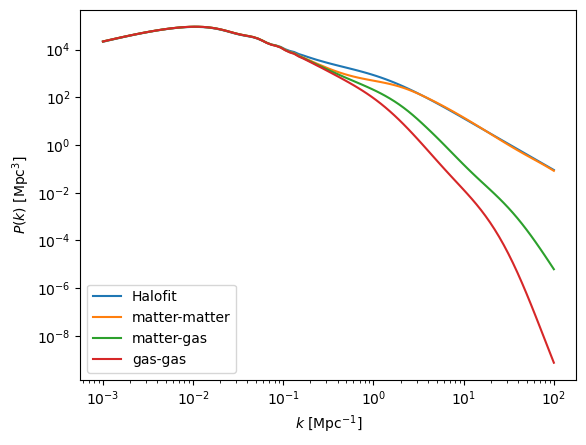

In [6]:
plt.plot(k_arr, cosmo.nonlin_matter_power(k_arr, 1.0), label='Halofit')
plt.plot(k_arr, pk_mm(k_arr, 1.0), label='matter-matter')
plt.plot(k_arr, pk_mg(k_arr, 1.0), label='matter-gas')
plt.plot(k_arr, pk_gg(k_arr, 1.0), label='gas-gas')
plt.loglog()
plt.xlabel(r'$k\,\,[{\rm Mpc}^{-1}]$')
plt.ylabel(r'$P(k)\,\,[{\rm Mpc}^3]$')
plt.legend()
plt.show()